# Demonotebook für ipycytoscape

In [1]:
%pip install -q ipycytoscape networkx
import ipycytoscape as cy
import networkx as nx
import pandas as pd

In [2]:
cyg = cy.CytoscapeWidget()
G = nx.complete_graph(5)

In [3]:
cyg.graph.add_graph_from_networkx(G)

In [4]:
cyg

CytoscapeWidget(cytoscape_layout={'name': 'cola'}, cytoscape_style=[{'selector': 'node', 'css': {'background-c…

## nx from pd

In [5]:
edges = pd.DataFrame(
    {
        "source": ["A", "A", "B", "C", "D"],
        "target": ["B", "C", "C", "D", "A"],
        "weight": [10, 8, 6, 2, 1],
        "color": ["red", "blue", "green", "yellow", "cyan"]
    }
)

In [6]:
edges

,source,target,weight,color
0,A,B,10,red
1,A,C,8,blue
2,B,C,6,green
3,C,D,2,yellow
4,D,A,1,cyan


In [7]:
G = nx.from_pandas_edgelist(edges, edge_attr=True)
cyg = cy.CytoscapeWidget()
cyg.graph.add_graph_from_networkx(G, directed=True)

In [8]:
my_style = [
    {
        'selector': 'node',
         'style': {
            'font-family': 'helvetica',
            'font-size': '20px',
            'label': 'data(id)'
         }
    },
    {
        'selector': 'edge',
        'style': {
            'font-family': 'helvetica',
            'font-size': '10px',
            'label': 'data(color)'
         }
    
    }
]

In [9]:
cyg.set_tooltip_source('source')
cyg.set_style(my_style)
cyg.set_layout(name = "dagre", nodeSpacing=10, edgeLengthVal=10)
cyg

CytoscapeWidget(cytoscape_layout={'name': 'dagre', 'nodeSpacing': 10, 'edgeLengthVal': 10}, cytoscape_style=[{…

In [10]:
print(nx.get_edge_attributes(G, "weight"))

{('A', 'B'): 10, ('A', 'C'): 8, ('A', 'D'): 1, ('B', 'C'): 6, ('C', 'D'): 2}


In [11]:
display(G.nodes)

NodeView(('A', 'B', 'C', 'D'))

In [12]:
pd.DataFrame(G.degree(), columns = ['id', 'degree'])

,id,degree
0,A,3
1,B,2
2,C,3
3,D,2


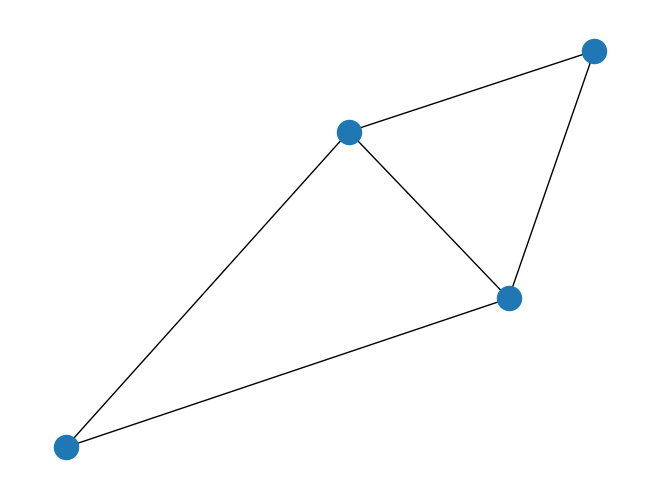

In [13]:
nx.draw(G)

In [14]:
edge_data = {
    'source': ['A', 'B', 'B', 'C'],
    'target': ['B', 'C', 'D', 'B'],
}
link_df = pd.DataFrame.from_dict(edge_data)
node_data = {
    'id': ['A', 'B', 'C', 'D', 'E']
}
node_df = pd.DataFrame.from_dict(node_data)

G = nx.from_pandas_edgelist(link_df)
node_df = pd.DataFrame(G.degree(), columns=['id', 'degree'])
print(node_df.set_index('id').to_dict('index'))
nx.set_node_attributes(G, node_df.set_index('id').to_dict('index'))
cytoscapeobj = cy.CytoscapeWidget()
cytoscapeobj.graph.add_graph_from_networkx(G)

cytoscapeobj.set_style(
    [
        {
             'selector': 'node',
             'style': {
                 'font-family': 'helvetica',
                 'font-size': '20px',
                 'label': 'data(id)'
             }
        },
        {
             'selector': 'edge',
             'style': {
                 'font-family': 'helvetica',
                 'font-size': '20px'
             }
        },
        {
             'selector': 'node[degree>0]',
             'style': {
                 'width': '100px',
                 'height': '100px'
             }
        },
        {
             'selector': 'node[degree>1]',
             'style': {
                 'width': '150px',
                 'height': '150px'
             }
        },
        {
             'selector': 'node[degree>2]',
             'style': {
                 'width': '200px',
                 'height': '200px'
             }
        }
    ]
)
cytoscapeobj

{'A': {'degree': 1}, 'B': {'degree': 3}, 'C': {'degree': 1}, 'D': {'degree': 1}}


CytoscapeWidget(cytoscape_layout={'name': 'cola'}, cytoscape_style=[{'selector': 'node', 'style': {'font-famil…

In [15]:
print(nx.get_node_attributes(G, "degree"))

{'A': 1, 'B': 3, 'C': 1, 'D': 1}
